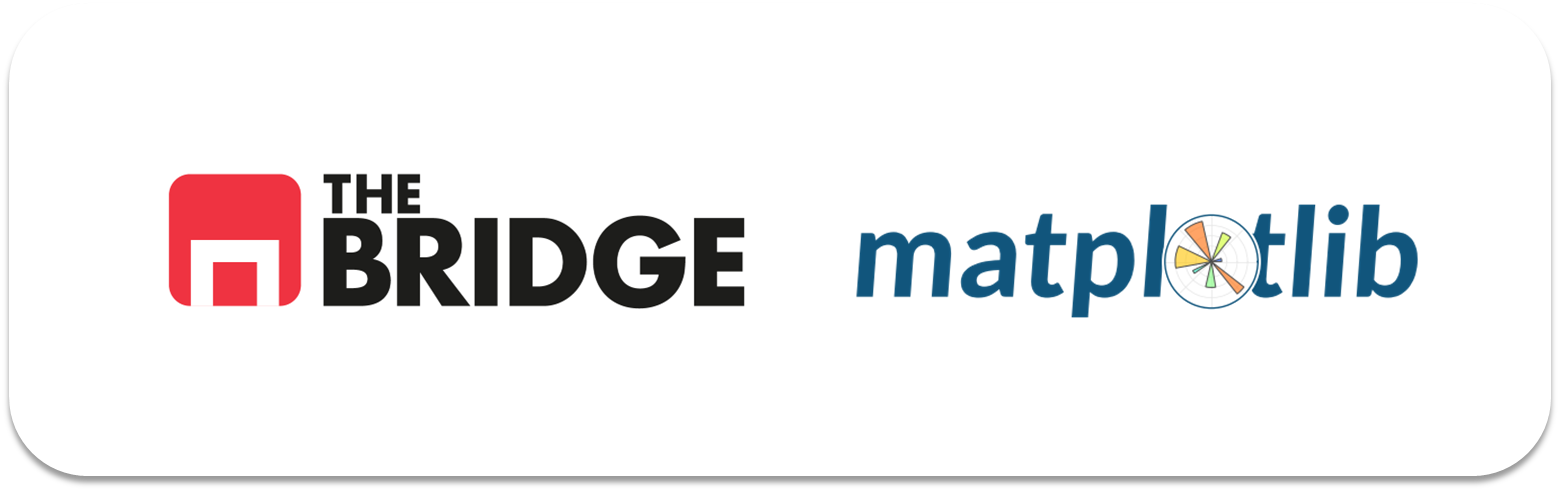

## PRACTICA OBLIGATORIA: **Visualización Básica**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Ejercicio 1

#### #1.1

- Carga el dataset de casas de California que está en la ruta "./data/california_cities.csv".  
- Muestra parte de su contenido y su descripción.  
- Deshazte de las filas con nulos.

In [2]:

df = pd.read_csv("./data/california_cities.csv")



In [3]:

print(df.head())

   Unnamed: 0         city       latd       longd  elevation_m  elevation_ft  \
0           0     Adelanto  34.576111 -117.432778        875.0        2871.0   
1           1  AgouraHills  34.153333 -118.761667        281.0         922.0   
2           2      Alameda  37.756111 -122.274444          NaN          33.0   
3           3       Albany  37.886944 -122.297778          NaN          43.0   
4           4     Alhambra  34.081944 -118.135000        150.0         492.0   

   population_total  area_total_sq_mi  area_land_sq_mi  area_water_sq_mi  \
0             31765            56.027           56.009             0.018   
1             20330             7.822            7.793             0.029   
2             75467            22.960           10.611            12.349   
3             18969             5.465            1.788             3.677   
4             83089             7.632            7.631             0.001   

   area_total_km2  area_land_km2  area_water_km2  area_water_p

In [4]:

print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          482 non-null    int64  
 1   city                482 non-null    object 
 2   latd                482 non-null    float64
 3   longd               482 non-null    float64
 4   elevation_m         434 non-null    float64
 5   elevation_ft        470 non-null    float64
 6   population_total    482 non-null    int64  
 7   area_total_sq_mi    480 non-null    float64
 8   area_land_sq_mi     482 non-null    float64
 9   area_water_sq_mi    481 non-null    float64
 10  area_total_km2      477 non-null    float64
 11  area_land_km2       478 non-null    float64
 12  area_water_km2      478 non-null    float64
 13  area_water_percent  477 non-null    float64
dtypes: float64(11), int64(2), object(1)
memory usage: 52.8+ KB
None


In [5]:
df = df.dropna()

#### #1.2  

Recrea la siguiente figura, para ello construye en apartados separados cada gráfico y luego haz un apartado en el que se junten los cuatro.  

Las figuras son:
1. Las ciudades más pobladas, con los numeros de las poblaciones (tendrás que usar texto y recordar que para centrarlos se necesita poner el argumento `ha` a "center" o investigar como funciona bar_label). Los colores de las barras deben tener un 50% de transparencia y ser: azul, gris, rojo, aceituna y marrón.  

2. Histograma del área total ocupada por las ciudades. (50 bins, fuente = "Arial", tamaño = 14, peso = "Bold", color azul acero o "steelblue")
3. El scatter de área de agua de un ciudad con su poblacion. Transparencia al 50% y color verde.
4. El boxplot de la altura de las ciudades.

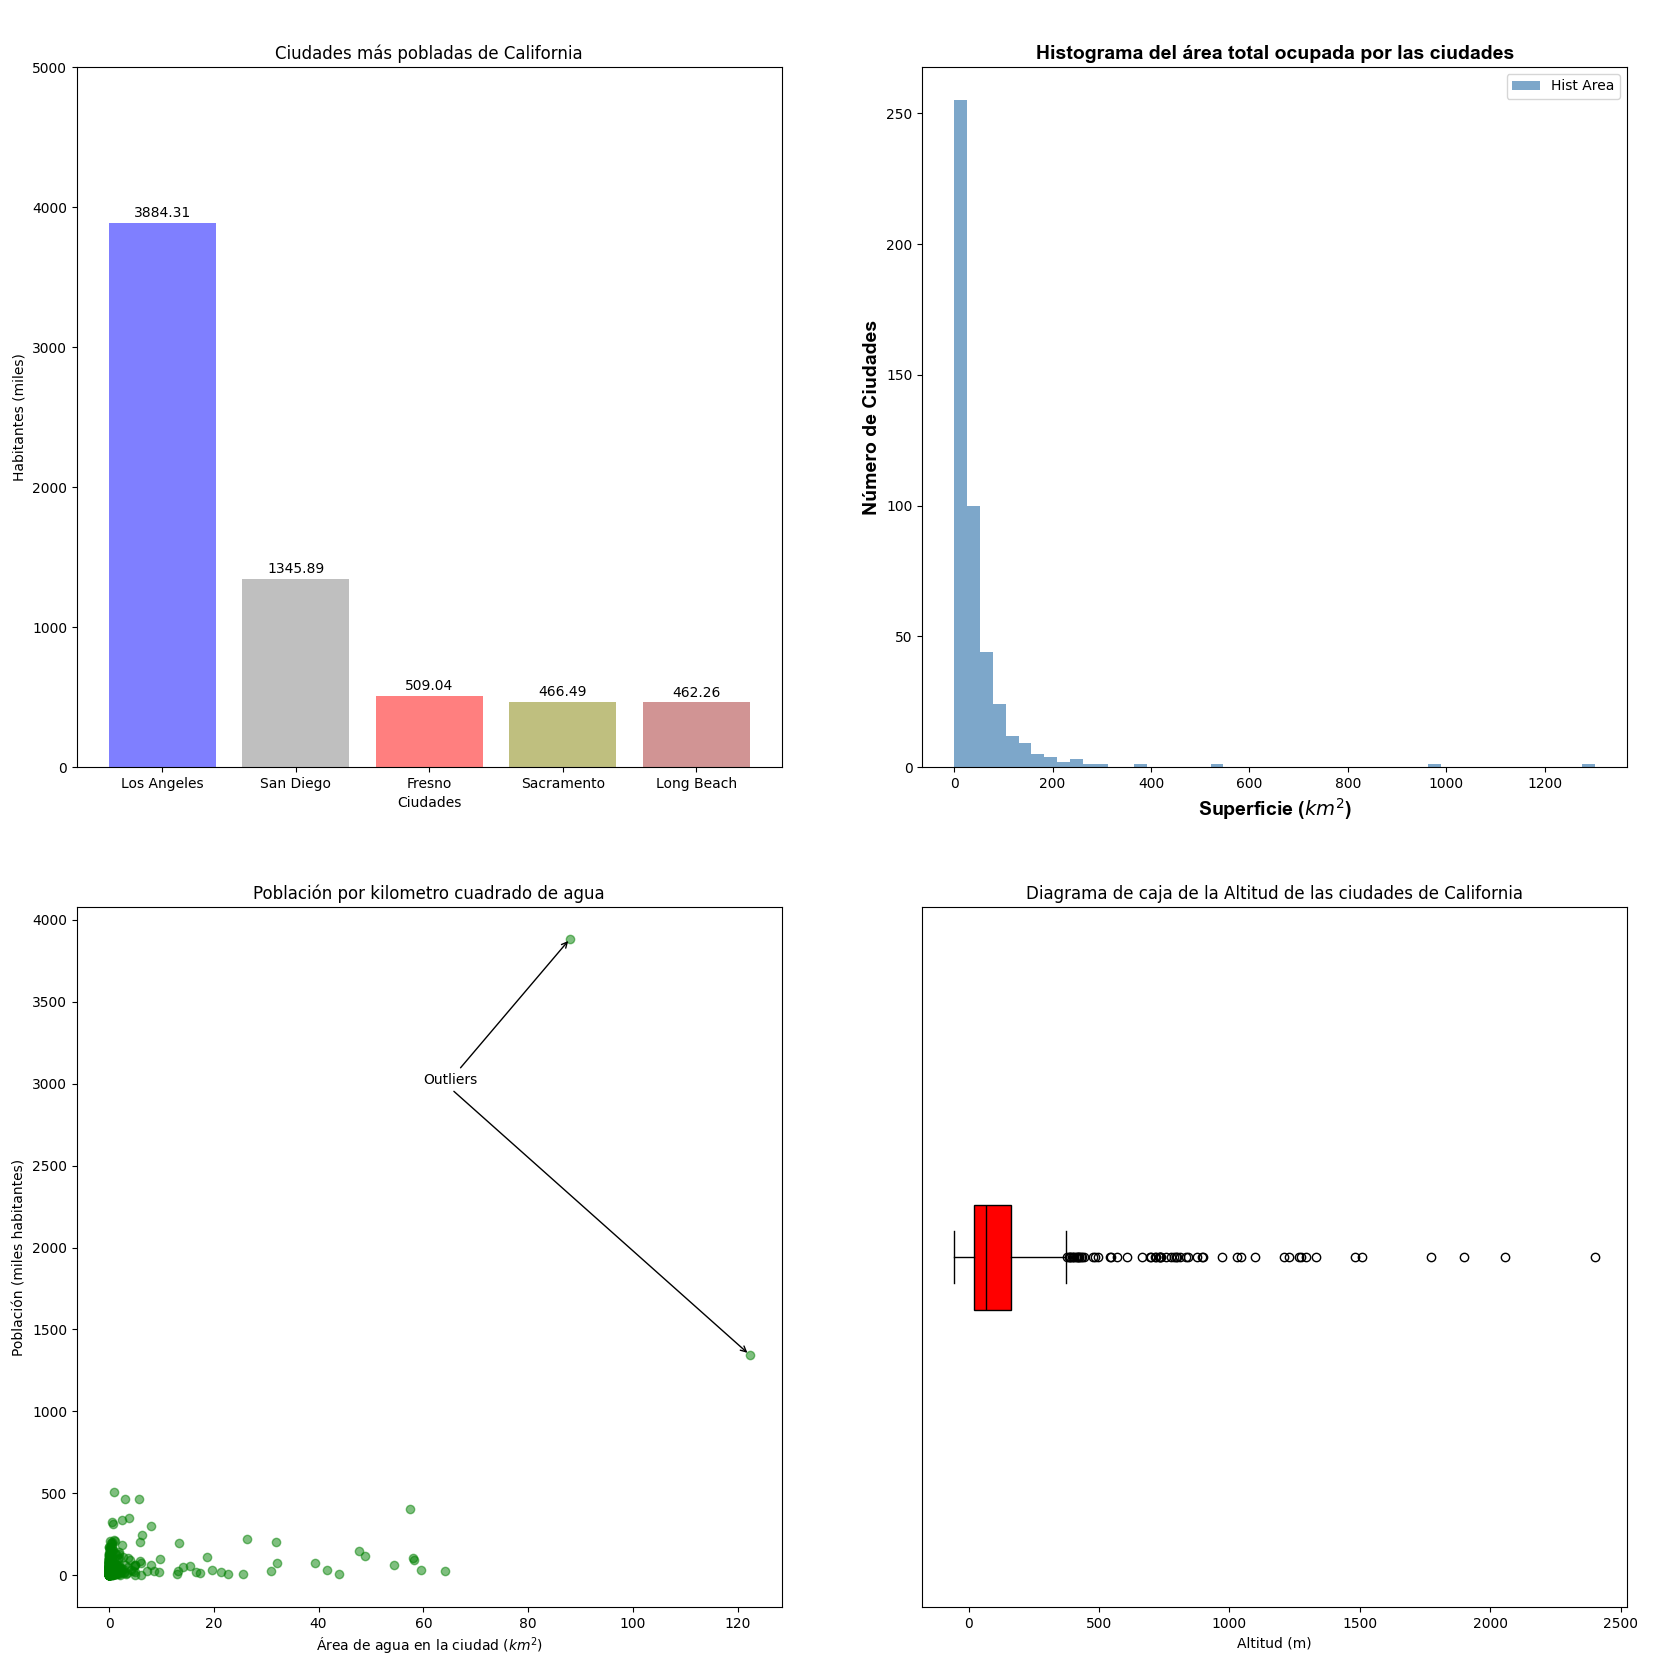

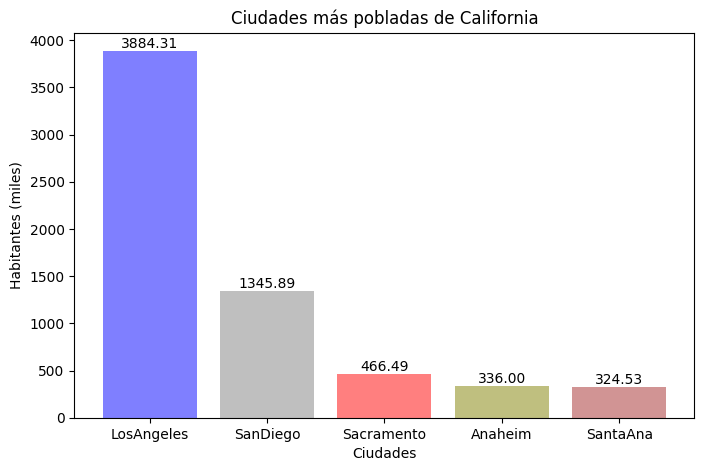

In [6]:
top5 = df.sort_values(by="population_total", ascending=False).head(5)

plt.figure(figsize=(8,5))

colors = ['blue', 'grey', 'red', 'olive', 'brown']

bars = plt.bar(top5["city"], top5["population_total"]/1000, 
               color=colors, alpha=0.5)


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.2f}', ha='center', va='bottom')

plt.title("Ciudades más pobladas de California")
plt.xlabel("Ciudades")
plt.ylabel("Habitantes (miles)")

plt.show()

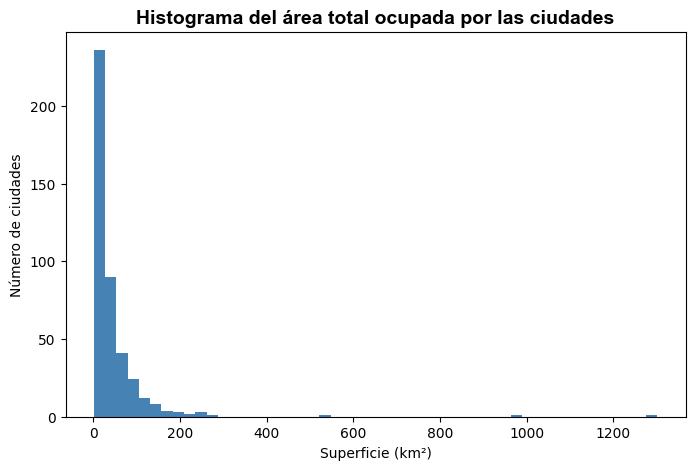

In [7]:
plt.figure(figsize=(8,5))

plt.hist(df["area_total_km2"], bins=50, color="steelblue")

plt.title("Histograma del área total ocupada por las ciudades",
          fontsize=14, fontweight='bold', fontname="Arial")
plt.xlabel("Superficie (km²)")
plt.ylabel("Número de ciudades")

plt.show()

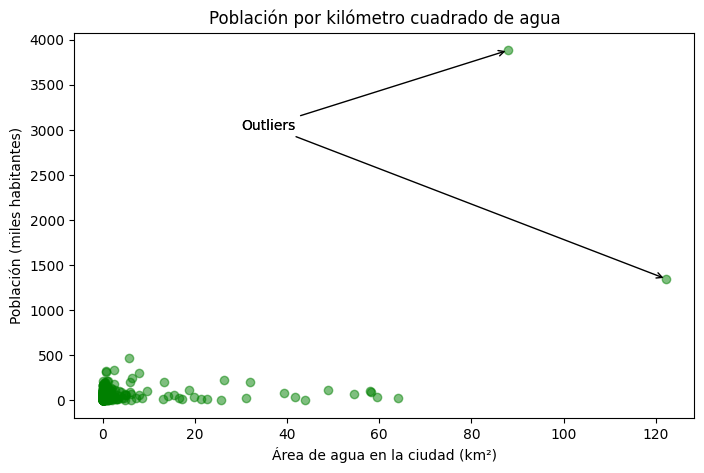

In [8]:
plt.figure(figsize=(8,5))

plt.scatter(df["area_water_km2"], df["population_total"]/1000,
            color="green", alpha=0.5)

plt.xlabel("Área de agua en la ciudad (km²)")
plt.ylabel("Población (miles habitantes)")
plt.title("Población por kilómetro cuadrado de agua")

# Ejemplo de anotación tipo "Outliers"
outliers = df.sort_values(by="population_total", ascending=False).head(2)

for _, row in outliers.iterrows():
    plt.annotate("Outliers",
                 (row["area_water_km2"], row["population_total"]/1000),
                 xytext=(30, 3000),
                 arrowprops=dict(arrowstyle="->"))

plt.show()

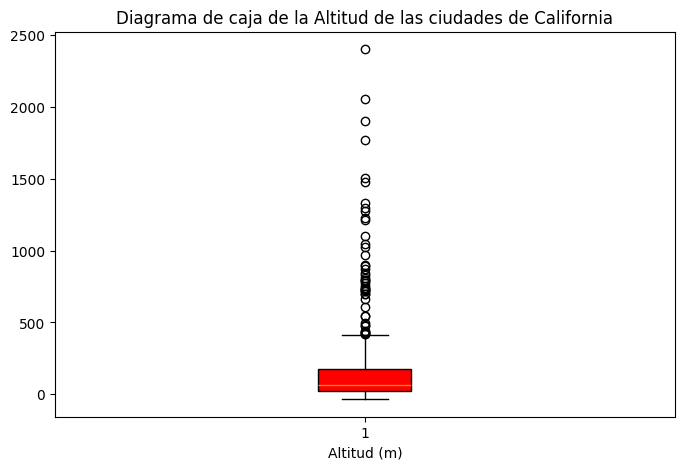

In [9]:
plt.figure(figsize=(8,5))

plt.boxplot(df["elevation_m"], patch_artist=True,
            boxprops=dict(facecolor="red"))

plt.title("Diagrama de caja de la Altitud de las ciudades de California")
plt.xlabel("Altitud (m)")

plt.show()

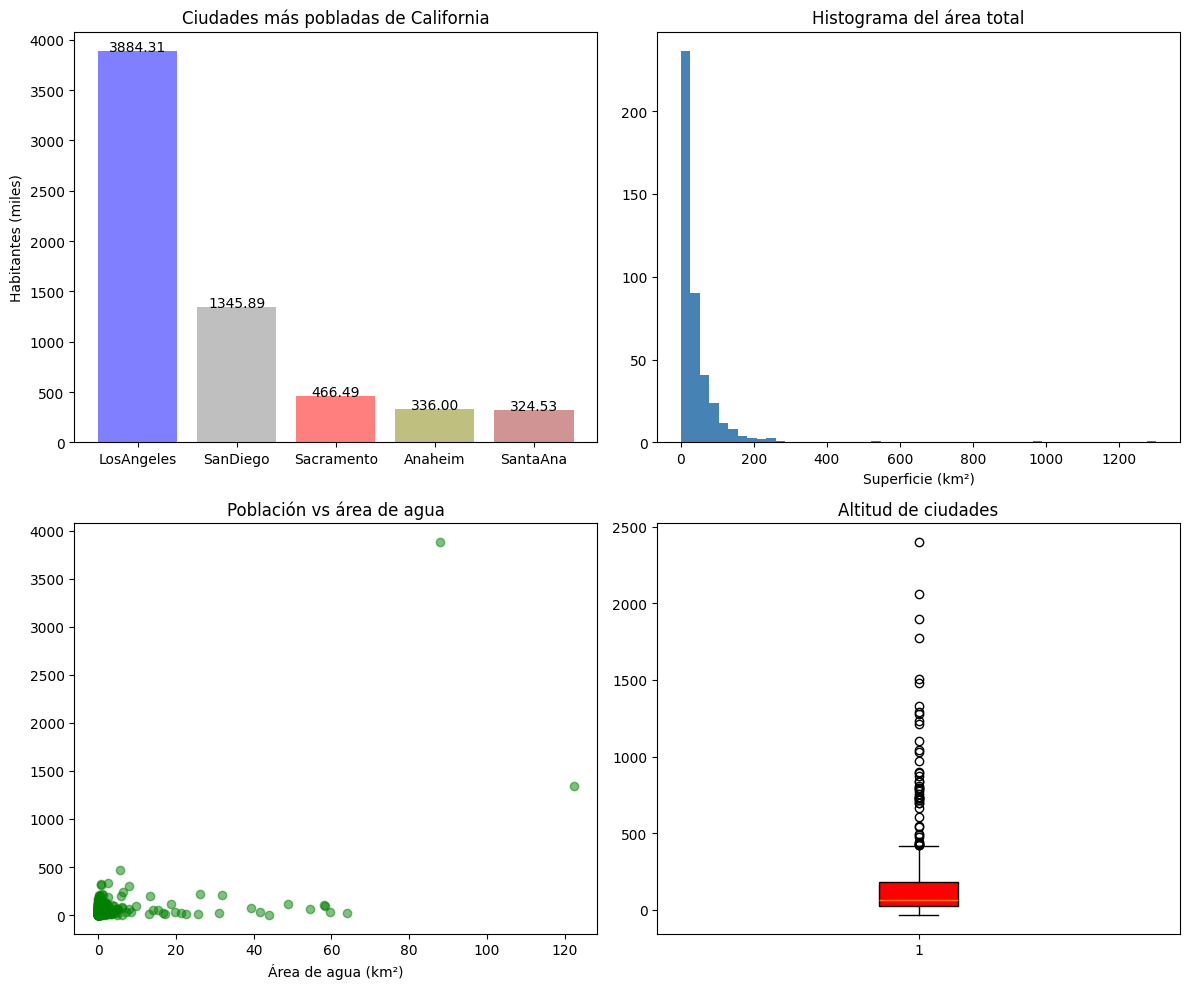

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(12,10))


top5 = df.sort_values(by="population_total", ascending=False).head(5)
colors = ['blue', 'grey', 'red', 'olive', 'brown']

bars = axs[0,0].bar(top5["city"], top5["population_total"]/1000,
                    color=colors, alpha=0.5)

for bar in bars:
    height = bar.get_height()
    axs[0,0].text(bar.get_x() + bar.get_width()/2, height,
                  f'{height:.2f}', ha='center')

axs[0,0].set_title("Ciudades más pobladas de California")
axs[0,0].set_ylabel("Habitantes (miles)")

axs[0,1].hist(df["area_total_km2"], bins=50, color="steelblue")
axs[0,1].set_title("Histograma del área total")
axs[0,1].set_xlabel("Superficie (km²)")


axs[1,0].scatter(df["area_water_km2"],
                 df["population_total"]/1000,
                 color="green", alpha=0.5)
axs[1,0].set_title("Población vs área de agua")
axs[1,0].set_xlabel("Área de agua (km²)")


axs[1,1].boxplot(df["elevation_m"], patch_artist=True,
                 boxprops=dict(facecolor="red"))
axs[1,1].set_title("Altitud de ciudades")

plt.tight_layout()
plt.show()

#### #1.3

Graba la figura en un archivo .png y sube el archivo a tu repositorio personal junto con el notebook.

In [12]:
fig.savefig("visualizacion.png")